# CP4 — Case iFood
## Parte 2 — Machine Learning & Modelling

Este notebook utiliza o dataset do Case iFood, previamente estruturado e validado no Oracle Database na Parte 1 do trabalho.

A seleção das variáveis segue a query documentada no arquivo `04_validation_and_ml_query.sql`.

O objetivo desta etapa é desenvolver uma versão melhorada do modelo Decision Tree apresentado no Case iFood, utilizando:

- análise exploratória objetiva;
- Feature Engineering;
- HoldOut estratificado;
- tuning de hiperparâmetros;
- avaliação por Precision, Recall, F1-score e ROC AUC;
- prevenção de data leakage.

## 1. Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)

## 2. Carregamento dos dados

Os dados utilizados correspondem ao dataset carregado na tabela `IFOOD_CUSTOMERS` do Oracle.

Para manter o notebook reproduzível localmente, o mesmo dataset original é carregado a partir do arquivo `data.csv`.

In [2]:
df = pd.read_csv("../data/data.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## 3. Conferência inicial dos dados

Nesta etapa são verificadas as dimensões do dataset, os tipos das variáveis, valores ausentes e a distribuição inicial da variável alvo `Response`.

In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
df["Response"].value_counts()

Response
0    1906
1     334
Name: count, dtype: int64

In [7]:
df["Response"].value_counts(normalize=True)

Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


### Observações iniciais

- O dataset possui 2240 registros.
- A variável `Income` possui valores ausentes.
- A variável alvo `Response` é desbalanceada, com predominância da classe 0.
- Essa característica será considerada posteriormente por meio de separação estratificada e tuning do modelo.

## 4. Tratamento inicial dos dados

Antes da análise exploratória, são realizados ajustes mínimos para permitir a criação das novas variáveis e manter consistência com o Case iFood apresentado em aula.

A variável `Income` possui valores ausentes. Nesta etapa, os valores nulos serão apenas identificados e preservados. O tratamento definitivo será realizado posteriormente dentro do pipeline de Machine Learning, evitando vazamento de dados.

In [9]:
df_ml = df.copy()

df_ml["Dt_Customer"] = pd.to_datetime(
    df_ml["Dt_Customer"],
    format="%Y-%m-%d",
    errors="coerce"
)

print("Valores nulos em Income:", df_ml["Income"].isna().sum())
print("Datas inválidas:", df_ml["Dt_Customer"].isna().sum())

Valores nulos em Income: 24
Datas inválidas: 0


## 5. Feature Engineering

O Case iFood apresentado em aula utiliza transformação de variáveis originais para representar melhor o perfil e o comportamento dos clientes.

Neste trabalho, são criadas novas features agregadas a partir de informações já disponíveis no momento da campanha. Nenhuma delas utiliza a variável alvo `Response`.

### 5.1 Idade do cliente

O notebook de aula transforma `Year_Birth` em idade. Para evitar utilizar o ano atual e tornar a análise reproduzível, será utilizado um ano de referência fixo compatível com o período do dataset.

In [10]:
REFERENCE_YEAR = 2017

df_ml["Age"] = REFERENCE_YEAR - df_ml["Year_Birth"]

df_ml[["Year_Birth", "Age"]].describe()

,Year_Birth,Age
count,2240.000000,2240.000000
mean,1968.805804,48.194196
std,11.984069,11.984069
min,1893.000000,21.000000
25%,1959.000000,40.000000
50%,1970.000000,47.000000
75%,1977.000000,58.000000
max,1996.000000,124.000000


### 5.2 Tempo como cliente

A data de cadastro `Dt_Customer` permite representar há quanto tempo o consumidor fazia parte da base. Essa variável pode capturar diferenças entre clientes novos e antigos.

In [11]:
REFERENCE_DATE = pd.Timestamp("2017-01-01")

df_ml["Customer_Tenure_Days"] = (
    REFERENCE_DATE - df_ml["Dt_Customer"]
).dt.days

df_ml["Customer_Tenure_Days"].describe()

count    2240.000000
mean     1270.582143
std       202.122512
min       917.000000
25%      1097.750000
50%      1272.500000
75%      1446.000000
max      1616.000000
Name: Customer_Tenure_Days, dtype: float64

### 5.3 Total de filhos no domicílio

As variáveis `Kidhome` e `Teenhome` representam crianças e adolescentes presentes no domicílio. A soma das duas fornece uma medida simples da quantidade total de dependentes.

In [12]:
df_ml["Total_Children"] = (
    df_ml["Kidhome"] +
    df_ml["Teenhome"]
)

df_ml["Total_Children"].value_counts().sort_index()

Total_Children
0     638
1    1128
2     421
3      53
Name: count, dtype: int64

### 5.4 Gasto total

As variáveis `Mnt...` representam gastos em diferentes categorias de produtos. A soma dessas categorias cria uma medida agregada do valor total consumido pelo cliente.

In [13]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df_ml["Total_Spent"] = df_ml[spending_cols].sum(axis=1)

df_ml["Total_Spent"].describe()

count    2240.000000
mean      605.798214
std       602.249288
min         5.000000
25%        68.750000
50%       396.000000
75%      1045.500000
max      2525.000000
Name: Total_Spent, dtype: float64

### 5.5 Total de compras

As compras realizadas pela web, catálogo e loja física representam canais diferentes de consumo. A soma fornece uma visão agregada da atividade de compra do cliente.

In [14]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df_ml["Total_Purchases"] = df_ml[purchase_cols].sum(axis=1)

df_ml["Total_Purchases"].describe()

count    2240.000000
mean       12.537054
std         7.205741
min         0.000000
25%         6.000000
50%        12.000000
75%        18.000000
max        32.000000
Name: Total_Purchases, dtype: float64

### 5.6 Campanhas anteriores aceitas

As variáveis `AcceptedCmp1` até `AcceptedCmp5` representam respostas a campanhas anteriores. A soma dessas variáveis indica o histórico de aceitação de campanhas do cliente.

Essa feature não utiliza `Response`, que representa a resposta da campanha atual.

In [15]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5"
]

df_ml["Accepted_Campaigns"] = df_ml[campaign_cols].sum(axis=1)

df_ml["Accepted_Campaigns"].value_counts().sort_index()

Accepted_Campaigns
0    1777
1     325
2      83
3      44
4      11
Name: count, dtype: int64

### 5.7 Ticket médio aproximado

A relação entre gasto total e quantidade total de compras cria uma estimativa simples do valor médio gasto por compra.

In [16]:
df_ml["Average_Ticket"] = np.where(
    df_ml["Total_Purchases"] > 0,
    df_ml["Total_Spent"] / df_ml["Total_Purchases"],
    0
)

df_ml["Average_Ticket"].describe()

count    2240.000000
mean       38.103486
std        45.910552
min         0.000000
25%        13.000000
50%        29.642857
75%        49.135417
max      1679.000000
Name: Average_Ticket, dtype: float64

## 6. Análise Exploratória de Dados — EDA

A EDA a seguir tem como objetivo verificar diferenças de perfil e comportamento entre clientes que responderam ou não à campanha e justificar as variáveis utilizadas posteriormente no modelo.

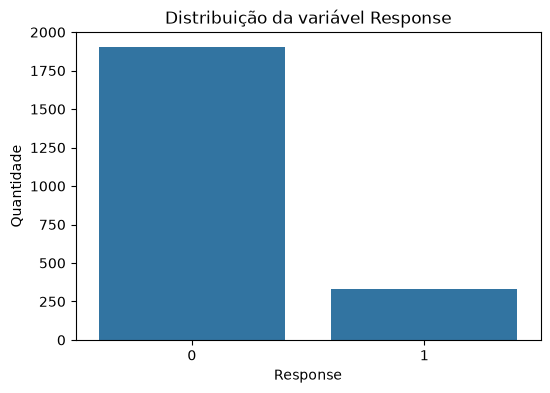

Response
0    1906
1     334
Name: count, dtype: int64
Response
0    0.850893
1    0.149107
Name: proportion, dtype: float64


In [17]:
response_counts = df_ml["Response"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.countplot(data=df_ml, x="Response")
plt.title("Distribuição da variável Response")
plt.xlabel("Response")
plt.ylabel("Quantidade")
plt.show()

print(response_counts)
print(df_ml["Response"].value_counts(normalize=True).sort_index())

### Interpretação

A variável alvo apresenta desbalanceamento entre as classes, com predominância de clientes que não responderam à campanha. Esse resultado justifica o uso de HoldOut estratificado e métricas além da acurácia, como Precision, Recall, F1-score e ROC AUC.

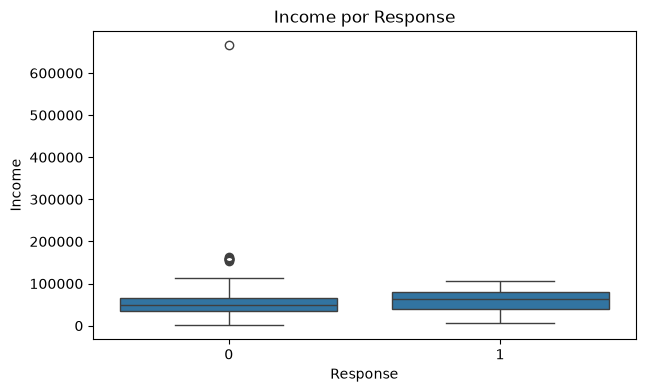

In [18]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Income")
plt.title("Income por Response")
plt.xlabel("Response")
plt.ylabel("Income")
plt.show()

### Interpretação

Os clientes com `Response = 1` apresentam renda geralmente superior aos clientes com `Response = 0`. Também foi observado um valor extremo de renda próximo de 666.666, pertencente à classe `Response = 0`. Os valores ausentes de `Income` serão tratados posteriormente dentro do pipeline.

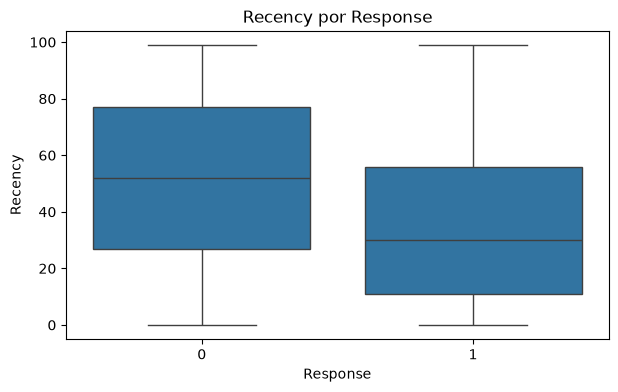

In [19]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Recency")
plt.title("Recency por Response")
plt.xlabel("Response")
plt.ylabel("Recency")
plt.show()

### Interpretação

Clientes com `Response = 1` apresentam valores menores de `Recency`. Isso indica que clientes que realizaram compras mais recentemente tiveram maior ocorrência de resposta positiva à campanha.

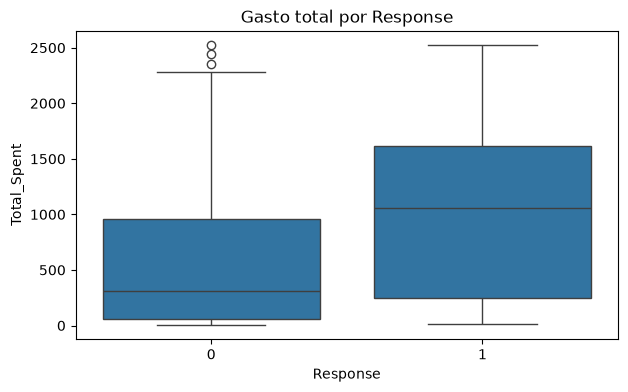

In [20]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Total_Spent")
plt.title("Gasto total por Response")
plt.xlabel("Response")
plt.ylabel("Total_Spent")
plt.show()

### Interpretação

A distribuição de `Total_Spent` é deslocada para valores maiores entre clientes com `Response = 1`. Isso indica associação entre maior gasto acumulado e maior ocorrência de resposta positiva.

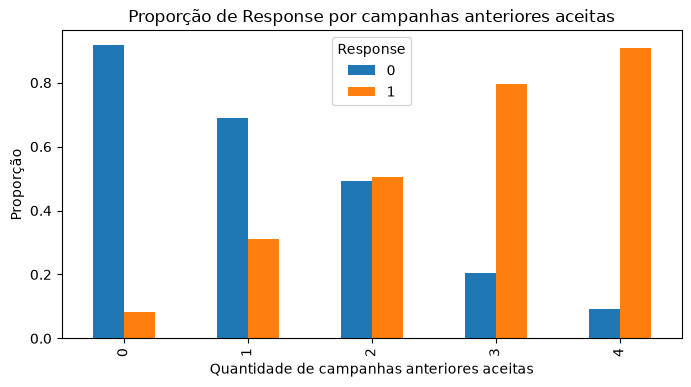

In [21]:
campaign_response = pd.crosstab(
    df_ml["Accepted_Campaigns"],
    df_ml["Response"],
    normalize="index"
)

campaign_response.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Proporção de Response por campanhas anteriores aceitas")
plt.xlabel("Quantidade de campanhas anteriores aceitas")
plt.ylabel("Proporção")
plt.legend(title="Response")
plt.show()

### Interpretação

A proporção de clientes com `Response = 1` aumenta conforme cresce o número de campanhas anteriores aceitas. Essa feature também apresentou a maior correlação numérica com `Response`, aproximadamente 0,426.

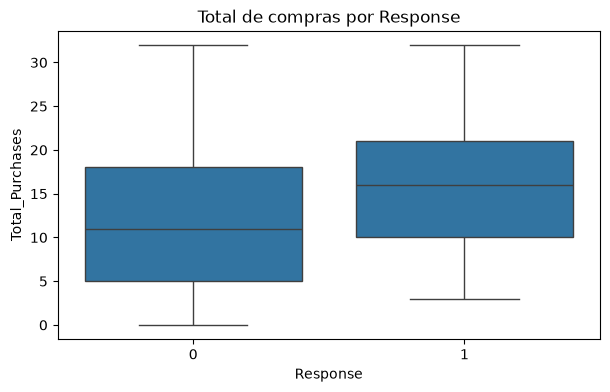

In [22]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df_ml, x="Response", y="Total_Purchases")
plt.title("Total de compras por Response")
plt.xlabel("Response")
plt.ylabel("Total_Purchases")
plt.show()

### Interpretação

Clientes com `Response = 1` apresentam, em geral, maior número total de compras. Isso sugere maior engajamento comercial entre os clientes que responderam positivamente.

In [23]:
numeric_df = df_ml.select_dtypes(include=np.number)

response_corr = (
    numeric_df
    .corr()["Response"]
    .drop("Response")
    .sort_values(key=abs, ascending=False)
)

response_corr.head(15)

Accepted_Campaigns      0.426035
AcceptedCmp5            0.326634
AcceptedCmp1            0.293982
Total_Spent             0.265298
AcceptedCmp3            0.254258
MntWines                0.247254
MntMeatProducts         0.236335
NumCatalogPurchases     0.220810
Recency                -0.198437
Customer_Tenure_Days    0.194481
AcceptedCmp4            0.177019
AcceptedCmp2            0.169293
Total_Children         -0.169163
Average_Ticket          0.165601
Total_Purchases         0.164688
Name: Response, dtype: float64

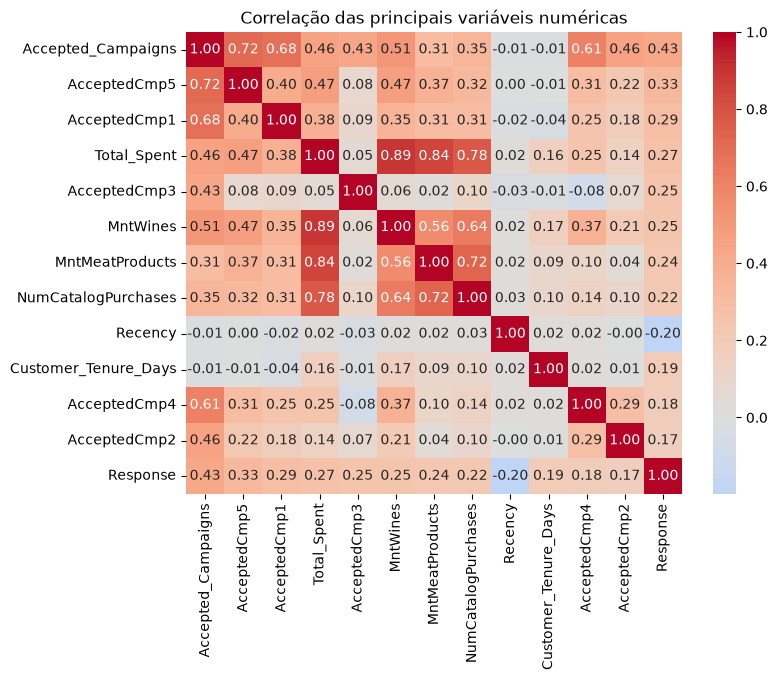

In [24]:
plt.figure(figsize=(8,6))

top_corr_cols = response_corr.head(12).index.tolist() + ["Response"]

sns.heatmap(
    df_ml[top_corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação das principais variáveis numéricas")
plt.show()

### Interpretação

A correlação não determina causalidade, mas ajuda a identificar quais variáveis numéricas apresentam maior associação linear com `Response`. Esse resultado será utilizado apenas como apoio exploratório, sem selecionar variáveis com base no conjunto de teste.

## 7. Resumo do Feature Engineering

Foram criadas as seguintes variáveis:

- `Age`: idade aproximada do cliente.
- `Customer_Tenure_Days`: tempo de relacionamento com a empresa.
- `Total_Children`: quantidade total de filhos no domicílio.
- `Total_Spent`: gasto agregado nas categorias de produtos.
- `Total_Purchases`: quantidade total de compras nos principais canais.
- `Accepted_Campaigns`: quantidade de campanhas anteriores aceitas.
- `Average_Ticket`: gasto médio aproximado por compra.

Essas features representam características demográficas, relacionamento com a empresa e comportamento de consumo, seguindo a lógica do Case iFood apresentado em aula e ampliando a representação das variáveis originais.

## 7.1 Verificação de valores extremos e inconsistências

A EDA identificou valores extremos e possíveis inconsistências que precisam ser documentados antes da modelagem, sem alterar o dataset original.

In [25]:
df_ml.loc[
    df_ml["Year_Birth"] < 1900,
    ["ID", "Year_Birth", "Age"]
]

,ID,Year_Birth,Age
239,11004,1893,124
339,1150,1899,118


In [26]:
df_ml.nlargest(
    10,
    "Income"
)[["ID", "Income"]]

,ID,Income
2233,9432,666666.0
617,1503,162397.0
687,1501,160803.0
1300,5336,157733.0
164,8475,157243.0
1653,4931,157146.0
2132,11181,156924.0
655,5555,153924.0
1898,4619,113734.0
646,4611,105471.0


In [27]:
df_ml.loc[
    (df_ml["Total_Purchases"] == 0) &
    (df_ml["Total_Spent"] > 0),
    ["ID", "Total_Spent", "Total_Purchases"]
]

,ID,Total_Spent,Total_Purchases
655,5555,6,0
981,3955,6,0
1245,6862,8,0
1524,11110,5,0
1846,9931,9,0
2132,11181,8,0


In [28]:
df_ml.nlargest(
    10,
    "Average_Ticket"
)[
    ["ID", "Total_Spent", "Total_Purchases", "Average_Ticket"]
]

,ID,Total_Spent,Total_Purchases,Average_Ticket
2228,8720,1679,1,1679.000000
644,1173,2252,12,187.666667
1328,4246,373,2,186.500000
1042,10749,178,1,178.000000
1001,7962,1901,11,172.818182
1749,737,2231,13,171.615385
2099,3422,1376,9,152.888889
715,10479,1511,10,151.100000
1179,5735,2525,17,148.529412
1572,5350,2525,17,148.529412


### Casos com gasto positivo e zero compras

Foram identificados seis registros em que `Total_Purchases = 0` enquanto `Total_Spent > 0`.

Isso ocorre porque `Total_Purchases` foi criado a partir da soma de:

- `NumWebPurchases`
- `NumCatalogPurchases`
- `NumStorePurchases`

Outras informações do dataset, como compras com desconto (`NumDealsPurchases`), não fazem parte dessa soma.

Como o denominador de `Average_Ticket` é zero nesses casos, o notebook define `Average_Ticket = 0` para evitar divisão por zero.

Esses registros foram mantidos e a situação foi documentada, em vez de removê-los automaticamente.

### Decisões para a modelagem

- `Dt_Customer` foi corrigida utilizando o formato real do CSV (`YYYY-MM-DD`).
- `Z_CostContact` e `Z_Revenue` serão removidas da modelagem por serem constantes.
- `ID` será removido das variáveis preditoras por funcionar apenas como identificador.
- Valores extremos de `Year_Birth`, `Income` e `Average_Ticket` serão documentados, mas não removidos automaticamente antes do HoldOut.
- O tratamento de valores ausentes de `Income` será realizado dentro do pipeline usando somente os dados de treino.
- Nenhuma decisão será tomada utilizando o conjunto de teste.

## 8. Preparação dos dados para modelagem

Nesta etapa, a variável alvo `Response` é separada das variáveis preditoras.

As colunas `ID`, `Z_CostContact` e `Z_Revenue` são removidas das variáveis de entrada:

- `ID` é apenas um identificador;
- `Z_CostContact` e `Z_Revenue` são constantes e não oferecem poder discriminativo para o modelo.

O conjunto de teste será separado antes do pré-processamento e ficará preservado para avaliação final.

In [29]:
model_df = df_ml.copy()

X = model_df.drop(
    columns=[
        "Response",
        "ID",
        "Z_CostContact",
        "Z_Revenue"
    ]
)

y = model_df["Response"]

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (2240, 32)
Formato de y: (2240,)


## 9. HoldOut estratificado

Como a variável `Response` apresenta desbalanceamento entre as classes, o HoldOut é realizado de forma estratificada.

Isso preserva aproximadamente a mesma proporção de `Response = 0` e `Response = 1` nos conjuntos de treino e teste.

O conjunto de teste será utilizado apenas para avaliação do modelo, evitando data leakage.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).sort_index())

Treino: (1792, 32)
Teste: (448, 32)

Distribuição no treino:
Response
0    0.851004
1    0.148996
Name: proportion, dtype: float64

Distribuição no teste:
Response
0    0.850446
1    0.149554
Name: proportion, dtype: float64


## 10. Pré-processamento

As variáveis categóricas serão transformadas utilizando `OneHotEncoder`.

As variáveis numéricas terão valores ausentes tratados com `SimpleImputer`, utilizando a mediana calculada apenas nos dados de treino durante o ajuste do pipeline.

In [31]:
from sklearn.impute import SimpleImputer

In [32]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Variáveis categóricas:")
print(categorical_features)

print("\nQuantidade de variáveis numéricas:")
print(len(numeric_features))

Variáveis categóricas:
['Education', 'Marital_Status']

Quantidade de variáveis numéricas:
29


## 11. Pipeline de pré-processamento

O uso de `Pipeline` e `ColumnTransformer` garante que o tratamento dos dados seja aprendido somente a partir do conjunto de treino.

Isso reduz o risco de data leakage.

### Tratamento de `Dt_Customer`

A coluna original `Dt_Customer` foi utilizada para a criação da feature `Customer_Tenure_Days`.

Como `Dt_Customer` possui tipo datetime e não faz parte das listas de variáveis numéricas ou categóricas utilizadas pelo `ColumnTransformer`, ela é descartada no pré-processamento.

Dessa forma, o modelo utiliza a informação temporal através de `Customer_Tenure_Days`, e não diretamente através da data original.

In [33]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

## 12. Decision Tree baseline

Antes do tuning, é criado um modelo baseline de Decision Tree.

O objetivo é estabelecer uma referência inicial para comparação com a versão otimizada.

O baseline será treinado somente com os dados de treino.

In [34]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['Year_Birth','Education','Marital_Status',...,'Total_Purchases', 'Accepted_Campaigns','Average_Ticket']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specif

## 13. Avaliação do modelo baseline

O modelo baseline é avaliado no conjunto de teste utilizando:

- Precision
- Recall
- F1-score
- ROC AUC

Além disso, são apresentadas a matriz de confusão e a curva ROC.

In [35]:
y_pred_baseline = baseline_pipeline.predict(X_test)

y_proba_baseline = baseline_pipeline.predict_proba(
    X_test
)[:, 1]

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_proba_baseline
)

baseline_results = pd.DataFrame(
    {
        "Modelo": ["Decision Tree Baseline"],
        "Precision": [baseline_precision],
        "Recall": [baseline_recall],
        "F1-score": [baseline_f1],
        "ROC AUC": [baseline_roc_auc]
    }
)

baseline_results

,Modelo,Precision,Recall,F1-score,ROC AUC
0,Decision Tree Baseline,0.515625,0.492537,0.503817,0.711776


In [36]:
print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       381
           1       0.52      0.49      0.50        67

    accuracy                           0.85       448
   macro avg       0.71      0.71      0.71       448
weighted avg       0.85      0.85      0.85       448



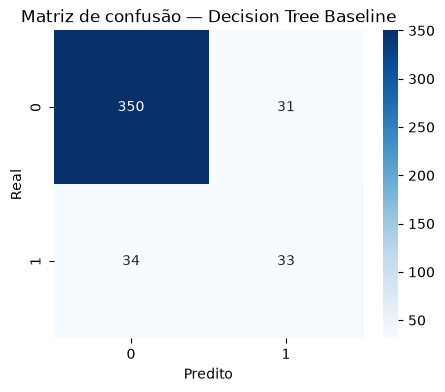

In [37]:
cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusão — Decision Tree Baseline")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

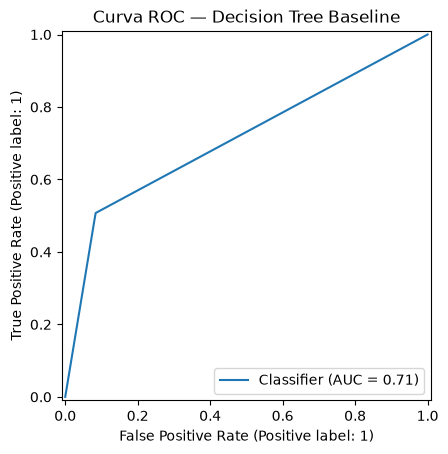

In [38]:
RocCurveDisplay.from_predictions(
    y_test,
    y_proba_baseline
)

plt.title("Curva ROC — Decision Tree Baseline")
plt.show()

## 14. Registro do baseline

Os resultados obtidos neste modelo serão utilizados como referência para comparar a Decision Tree otimizada posteriormente.

O tuning será realizado exclusivamente com o conjunto de treino, utilizando validação cruzada estratificada.

O conjunto de teste não será utilizado na escolha dos hiperparâmetros.

## 15. Tuning da Decision Tree

O modelo baseline utiliza os hiperparâmetros padrão da `DecisionTreeClassifier`.

Nesta etapa, os hiperparâmetros serão ajustados utilizando `GridSearchCV` com validação cruzada estratificada de 5 folds.

Todo o processo de seleção será realizado exclusivamente sobre o conjunto de treino.

A métrica utilizada para selecionar a melhor configuração será `ROC AUC`, adequada para avaliar a capacidade de discriminação do modelo em diferentes limiares de classificação.

In [39]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tuning_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

param_grid = {
    "classifier__criterion": [
        "gini",
        "entropy"
    ],
    "classifier__max_depth": [
        3,
        4,
        5,
        6,
        8,
        None
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],
    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [3, 4, ...], 'classifier__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes

## 16. Resultado do tuning

A configuração abaixo foi escolhida exclusivamente a partir da validação cruzada realizada sobre os dados de treino.

O conjunto de teste ainda não participou da escolha dos hiperparâmetros.

In [40]:
print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print(
    "\nMelhor ROC AUC médio na validação cruzada:",
    grid_search.best_score_
)

Melhores hiperparâmetros:
{'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}

Melhor ROC AUC médio na validação cruzada: 0.8151942353736354


In [41]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

top_cv_results = (
    cv_results[
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "params"
        ]
    ]
    .sort_values("rank_test_score")
    .head(10)
)

top_cv_results

,rank_test_score,mean_test_score,std_test_score,mean_train_score,params
124,1,0.815194,0.020423,0.881924,"{'classifier__class_weight': None, 'classifier..."
125,1,0.815194,0.020423,0.881924,"{'classifier__class_weight': None, 'classifier..."
126,1,0.815194,0.020423,0.881924,"{'classifier__class_weight': None, 'classifier..."
127,1,0.815194,0.020423,0.881924,"{'classifier__class_weight': None, 'classifier..."
312,5,0.811857,0.016281,0.878747,"{'classifier__class_weight': 'balanced', 'clas..."
313,5,0.811857,0.016281,0.878747,"{'classifier__class_weight': 'balanced', 'clas..."
314,5,0.811857,0.016281,0.878747,"{'classifier__class_weight': 'balanced', 'clas..."
380,8,0.810288,0.009997,0.965299,"{'classifier__class_weight': 'balanced', 'clas..."
383,8,0.810288,0.009997,0.965299,"{'classifier__class_weight': 'balanced', 'clas..."
382,8,0.810288,0.009997,0.965299,"{'classifier__class_weight': 'balanced', 'clas..."


## 17. Modelo final otimizado

Após a escolha dos hiperparâmetros por validação cruzada, o melhor modelo é utilizado para realizar a avaliação final no conjunto de teste preservado.

O conjunto de teste também foi utilizado anteriormente para avaliar o baseline. Entretanto, seus resultados não foram utilizados para selecionar hiperparâmetros: o `GridSearchCV` realizou toda a seleção exclusivamente sobre os dados de treino.

In [42]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(
    X_test
)

y_proba_tuned = best_model.predict_proba(
    X_test
)[:, 1]

In [43]:
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    y_proba_tuned
)

tuned_results = pd.DataFrame(
    {
        "Modelo": ["Decision Tree Otimizada"],
        "Precision": [tuned_precision],
        "Recall": [tuned_recall],
        "F1-score": [tuned_f1],
        "ROC AUC": [tuned_roc_auc]
    }
)

tuned_results

,Modelo,Precision,Recall,F1-score,ROC AUC
0,Decision Tree Otimizada,0.470588,0.238806,0.316832,0.783543


In [44]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       381
           1       0.47      0.24      0.32        67

    accuracy                           0.85       448
   macro avg       0.67      0.60      0.62       448
weighted avg       0.82      0.85      0.82       448



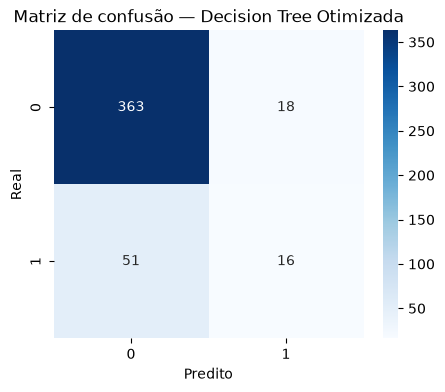

In [45]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusão — Decision Tree Otimizada")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## 18. Comparação dos modelos

A comparação utiliza o mesmo conjunto de teste para os dois modelos.

O baseline fornece a referência inicial, enquanto o modelo otimizado foi selecionado exclusivamente por validação cruzada nos dados de treino.

In [46]:
comparison = pd.concat(
    [
        baseline_results,
        tuned_results
    ],
    ignore_index=True
)

comparison

,Modelo,Precision,Recall,F1-score,ROC AUC
0,Decision Tree Baseline,0.515625,0.492537,0.503817,0.711776
1,Decision Tree Otimizada,0.470588,0.238806,0.316832,0.783543


In [47]:
roc_improvement = (
    tuned_roc_auc -
    baseline_roc_auc
)

print(
    "Diferença de ROC AUC:",
    roc_improvement
)

Diferença de ROC AUC: 0.07176714850942145


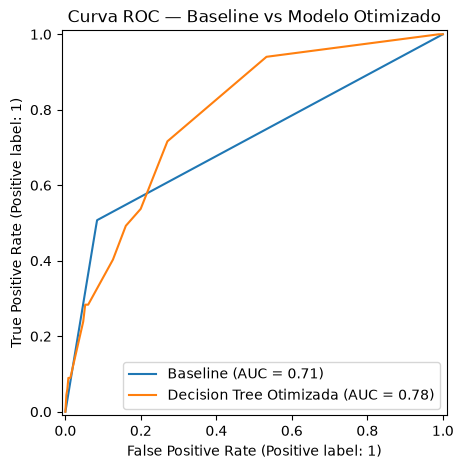

In [48]:
fig, ax = plt.subplots(figsize=(7,5))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_baseline,
    name="Baseline",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_tuned,
    name="Decision Tree Otimizada",
    ax=ax
)

plt.title("Curva ROC — Baseline vs Modelo Otimizado")
plt.show()

## 19. Conclusão da modelagem

O tuning aumentou o ROC AUC, enquanto Precision, Recall e F1-score diminuíram no limiar padrão de classificação. Os valores abaixo sintetizam essa diferença antes da conclusão acadêmica final.

In [49]:
print(f"ROC AUC baseline: {baseline_roc_auc:.4f}")
print(f"ROC AUC otimizado: {tuned_roc_auc:.4f}")
print(f"Variação: {roc_improvement:+.4f}")

ROC AUC baseline: 0.7118
ROC AUC otimizado: 0.7835
Variação: +0.0718


# 20. Conclusão final

O objetivo desta etapa foi melhorar a Decision Tree utilizada como referência no Case iFood, aplicando Feature Engineering, HoldOut estratificado, pipeline de pré-processamento e tuning de hiperparâmetros com validação cruzada.

A Decision Tree baseline apresentou:

- Precision: 0,5156
- Recall: 0,4925
- F1-score: 0,5038
- ROC AUC: 0,7118

Após o tuning com GridSearchCV e validação cruzada estratificada de 5 folds, os melhores hiperparâmetros encontrados foram:

- criterion = entropy
- max_depth = 4
- min_samples_leaf = 10
- min_samples_split = 2
- class_weight = None

O melhor ROC AUC médio observado durante a validação cruzada foi de 0,8152.

Na avaliação final realizada no conjunto de teste preservado, o modelo otimizado apresentou:

- Precision: 0,4706
- Recall: 0,2388
- F1-score: 0,3168
- ROC AUC: 0,7835

Em comparação com o baseline, houve aumento de aproximadamente 0,0718 no ROC AUC.

Esse resultado indica que o modelo otimizado apresentou maior capacidade global de discriminação entre clientes que responderam ou não à campanha.

Entretanto, no limiar padrão de classificação de 0,5, houve redução de Recall e F1-score. A matriz de confusão mostra que o modelo passou a ser mais conservador na identificação da classe positiva, gerando mais falsos negativos.

Portanto, a melhoria do modelo não ocorreu de forma uniforme em todas as métricas. O principal ganho foi observado no ROC AUC, que era o foco definido no desafio do trabalho.

O processo foi realizado sem data leakage:

- o HoldOut foi estratificado;
- o conjunto de teste foi separado antes do pré-processamento;
- imputação e codificação foram realizadas dentro do pipeline;
- o GridSearchCV utilizou somente os dados de treino;
- o conjunto de teste foi utilizado para avaliar o baseline e, posteriormente, o modelo otimizado; seus resultados não foram utilizados para selecionar hiperparâmetros, e o GridSearchCV realizou toda a seleção exclusivamente sobre os dados de treino.

As features criadas durante o Feature Engineering, como `Total_Spent`, `Total_Purchases`, `Accepted_Campaigns`, `Total_Children`, `Age`, `Customer_Tenure_Days` e `Average_Ticket`, ampliaram a representação do comportamento dos clientes e contribuíram para uma modelagem mais estruturada.

In [50]:
final_comparison = pd.DataFrame({
    "Modelo": [
        "Decision Tree Baseline",
        "Decision Tree Otimizada"
    ],
    "Precision": [
        baseline_precision,
        tuned_precision
    ],
    "Recall": [
        baseline_recall,
        tuned_recall
    ],
    "F1-score": [
        baseline_f1,
        tuned_f1
    ],
    "ROC AUC": [
        baseline_roc_auc,
        tuned_roc_auc
    ]
})

final_comparison

                    Modelo  Precision    Recall  F1-score   ROC AUC
0   Decision Tree Baseline   0.515625  0.492537  0.503817  0.711776
1  Decision Tree Otimizada   0.470588  0.238806  0.316832  0.783543

## Resumo

- Dataset: 2.240 registros
- Target: `Response`
- HoldOut: 80% treino / 20% teste, com estratificação
- Validação cruzada: StratifiedKFold com 5 folds
- Modelo: Decision Tree
- Métrica principal de tuning: ROC AUC
- ROC AUC baseline: 0,7118
- ROC AUC final: 0,7835
- Melhoria absoluta: +0,0718
- Processo realizado sem data leakage